In [1]:
!pip install tqdm scipy

# Connection to the thymio

In [2]:
from tdmclient import ClientAsync
client = ClientAsync()
node = await client.wait_for_node()
await node.lock()

ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

# Extended Kalman Filter (EKF) for Thymio 2D Pose

This notebook implements an EKF for a unicycle-type robot:

- State: x = [x, y, theta]^T
- Prediction: uses odometry (v, omega)
- Update: uses camera pose measurement [x_cam, y_cam, theta_cam]^T

You can:
- Tune process noise Q and measurement noise R
- Simulate robot motion
- See how the EKF corrects the estimate with noisy camera measurements


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling period
Ts = 0.1       # 10 Hz simulation

# Process noise (model / wheel uncertainty)
Q = np.diag([0.005, 0.005, 0.002])

# Measurement noise (camera)
R_cam = np.diag([0.002, 0.002, 0.0005])   # trustworthy camera


# Duration of simulation
T_total = 20.0
steps = int(T_total / Ts)


In [4]:
def wrap_angle(angle):
    """Keep angle in [-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


In [5]:
def ekf_predict(x, P, v, omega, Ts, Q):
    x_pos, y_pos, theta = x.flatten()

    # Nonlinear prediction
    x_pos_pred = x_pos + Ts * v * np.cos(theta)
    y_pos_pred = y_pos + Ts * v * np.sin(theta)
    theta_pred = wrap_angle(theta + Ts * omega)

    x_pred = np.array([[x_pos_pred],
                       [y_pos_pred],
                       [theta_pred]])

    # Jacobian A
    A = np.array([
        [1, 0, -Ts * v * np.sin(theta)],
        [0, 1,  Ts * v * np.cos(theta)],
        [0, 0,  1]
    ])

    # Covariance prediction
    P_pred = A @ P @ A.T + Q
    return x_pred, P_pred


In [6]:
def ekf_update_camera(x_pred, P_pred, z_cam, R_cam):
    H = np.eye(3)

    # Innovation
    y = z_cam - H @ x_pred
    y[2, 0] = wrap_angle(y[2, 0])

    # Innovation covariance
    S = H @ P_pred @ H.T + R_cam

    # Kalman gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Updated state
    x_upd = x_pred + K @ y
    x_upd[2, 0] = wrap_angle(x_upd[2, 0])

    # Updated covariance
    P_upd = P_pred - K @ H @ P_pred

    return x_upd, P_upd, K, y


In [7]:
# True state
x_true = np.array([[0.0], [0.0], [0.0]])

# EKF initial estimate
x_est = np.array([[0.0], [0.0], [0.0]])
P_est = np.diag([1.0, 1.0, 0.5])

# Logs
true_path = []
odometry_log = []
camera_log = []
est_path = []
pred_path = []          # predicted state before correction
camera_path = []        # camera measurements (when visible, else NaN)
camera_availability = []

P_trace = []   # to store trace(P) = measure of uncertainty
P_x = []       # uncertainty in x (P[0,0])
P_y = []       # uncertainty in y (P[1,1])
P_theta = []   # uncertainty in theta (P[2,2])

K_x = []                # Kalman gain on x
K_y = []                # Kalman gain on y
K_theta = []            # Kalman gain on theta
innov_norm = []         # innovation norm (for “surprise”)


for k in range(steps):
    
    t = k * Ts
    
    # ---------- TRUE MOTION ----------
    # Robot drives in a curve
    v_true = 0.15
    omega_true = 0.15 * np.sin(0.2 * t)

    x_true[0,0] += Ts * v_true * np.cos(x_true[2,0])
    x_true[1,0] += Ts * v_true * np.sin(x_true[2,0])
    x_true[2,0] = wrap_angle(x_true[2,0] + Ts * omega_true)

    # ---------- SENSOR SIMULATION ----------
    # Wheel odometry = true motion + noise
    # Wheel odometry = true motion + bias + noise
 # Fixed (systematic) bias on odometry, no randomness
    bias_v = 0.02       # e.g. wheels always report +0.02 m/s too much
    bias_omega = 0.03   # e.g. orientation always grows +0.03 rad/s too much

    v_wheel = v_true + bias_v
    omega_wheel = omega_true + bias_omega



    # Camera "covered" between t = 8s and 14s
    cam_visible = not (8.0 < t < 14.0)

    if cam_visible:
        z_cam = np.array([
        [x_true[0,0] + np.random.normal(0, 0.003)],
        [x_true[1,0] + np.random.normal(0, 0.003)],
        [wrap_angle(x_true[2,0] + np.random.normal(0, 0.01))]
    ])
        camera_path.append(z_cam.flatten())
    else:
        z_cam = None
        camera_path.append([np.nan, np.nan, np.nan])


    # ---------- EKF PREDICTION ----------
    x_pred, P_pred = ekf_predict(x_est, P_est, v_wheel, omega_wheel, Ts, Q)

    # Log predicted state
    pred_path.append(x_pred.flatten())

    # ---------- EKF UPDATE (camera only if visible) ----------
    if cam_visible and z_cam is not None:
        x_est, P_est, K, y = ekf_update_camera(x_pred, P_pred, z_cam, R_cam)

        # Log main diagonal of K (identity H => these are the useful ones)
        K_x.append(K[0, 0])
        K_y.append(K[1, 1])
        K_theta.append(K[2, 2])

        # Log innovation norm
        innov_norm.append(float(np.linalg.norm(y)))
    else:
        x_est, P_est = x_pred, P_pred

        # When no update, gains and innovation are “none”
        K_x.append(0.0)
        K_y.append(0.0)
        K_theta.append(0.0)
        innov_norm.append(0.0)


    # Save logs
    true_path.append(x_true.flatten())
    est_path.append(x_est.flatten())
    odometry_log.append([v_wheel, omega_wheel])
    camera_availability.append(cam_visible)
    # Log covariance evolution
    P_trace.append(np.trace(P_est))   # total uncertainty
    P_x.append(P_est[0,0])
    P_y.append(P_est[1,1])
    P_theta.append(P_est[2,2])



# Plotting 

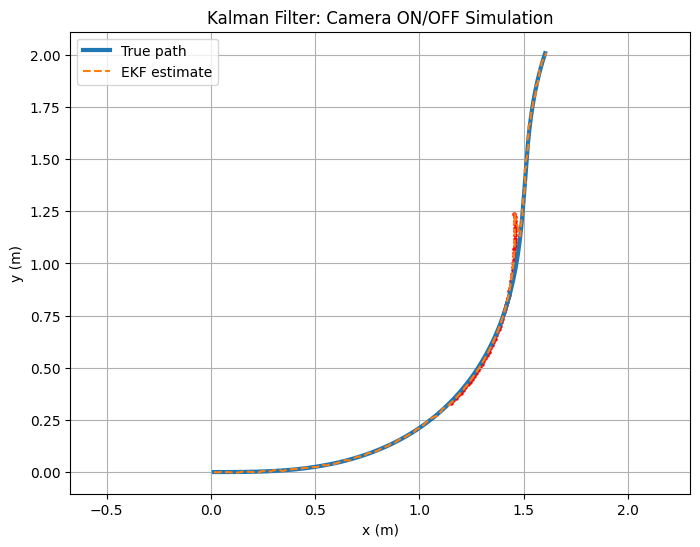

In [8]:
true_path = np.array(true_path)
est_path = np.array(est_path)

plt.figure(figsize=(8,6))
plt.plot(true_path[:,0], true_path[:,1], label="True path", linewidth=3)
plt.plot(est_path[:,0], est_path[:,1], label="EKF estimate", linestyle="--")

# Mark camera-off zone in red
for k, visible in enumerate(camera_availability):
    if not visible:
        plt.scatter(est_path[k,0], est_path[k,1], color='red', s=5)

plt.legend()
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Kalman Filter: Camera ON/OFF Simulation")
plt.grid(True)
plt.axis("equal")
plt.show()


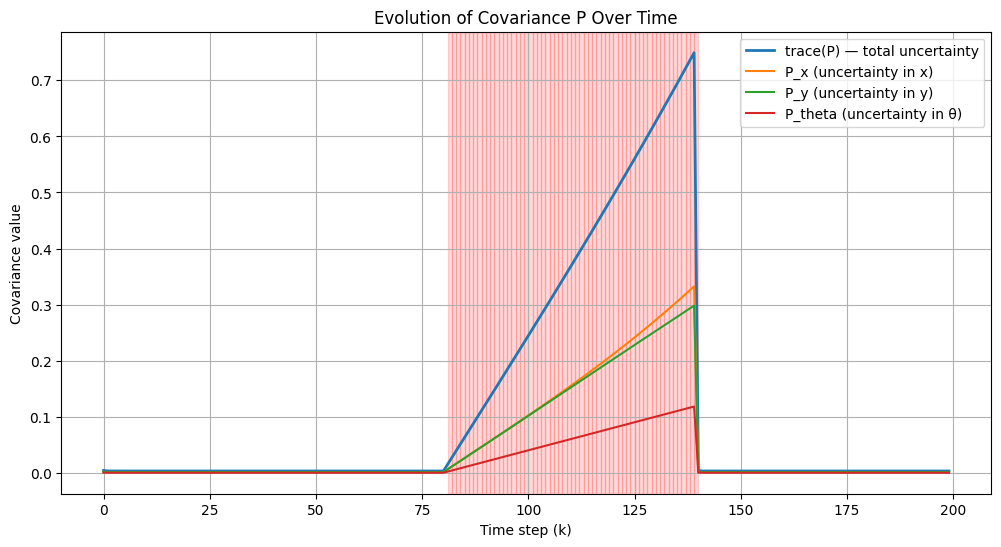

In [41]:
plt.figure(figsize=(12,6))

plt.plot(P_trace, label='trace(P) — total uncertainty', linewidth=2)
plt.plot(P_x, label='P_x (uncertainty in x)')
plt.plot(P_y, label='P_y (uncertainty in y)')
plt.plot(P_theta, label='P_theta (uncertainty in θ)')

# Highlight camera ON/OFF intervals
for k, visible in enumerate(camera_availability):
    if not visible:
        plt.axvspan(k, k+1, color='red', alpha=0.15)

plt.title("Evolution of Covariance P Over Time")
plt.xlabel("Time step (k)")
plt.ylabel("Covariance value")
plt.legend()
plt.grid(True)
plt.show()


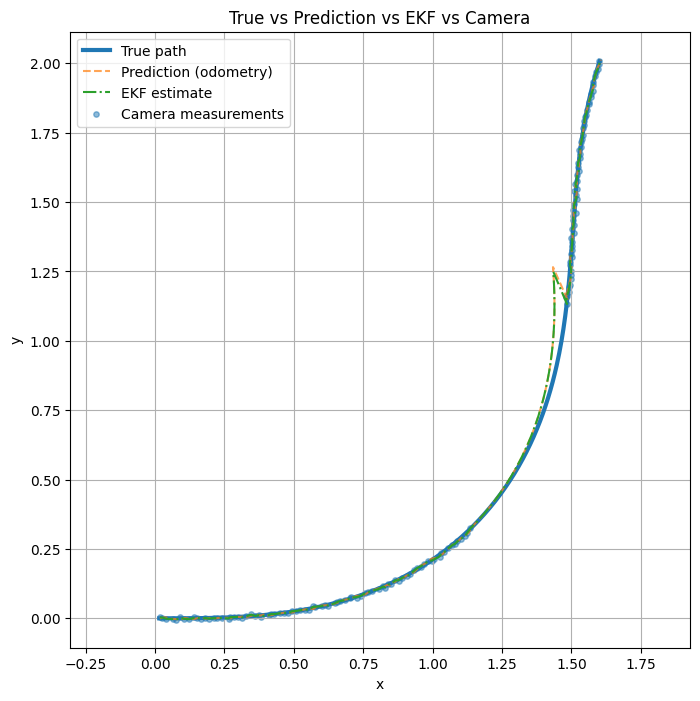

In [42]:
true_path = np.array(true_path)
est_path = np.array(est_path)
pred_path = np.array(pred_path)
camera_path = np.array(camera_path)

plt.figure(figsize=(8,8))

# True path
plt.plot(true_path[:,0], true_path[:,1], label="True path", linewidth=3)

# Predicted (odometry-only) path
plt.plot(pred_path[:,0], pred_path[:,1], label="Prediction (odometry)", linestyle="--", alpha=0.7)

# EKF corrected estimate
plt.plot(est_path[:,0], est_path[:,1], label="EKF estimate", linestyle="-.")

# Camera measurements (scatter)
plt.scatter(camera_path[:,0], camera_path[:,1], label="Camera measurements", s=15, alpha=0.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("True vs Prediction vs EKF vs Camera")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()


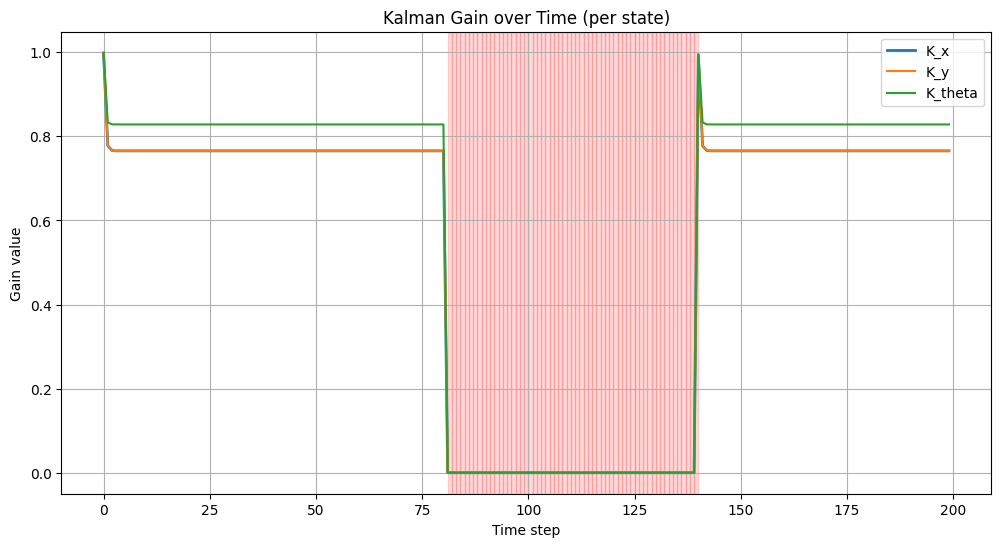

In [43]:
plt.figure(figsize=(12,6))

plt.plot(K_x, label="K_x", linewidth=2)
plt.plot(K_y, label="K_y")
plt.plot(K_theta, label="K_theta")

# Shade camera-off intervals
for k, visible in enumerate(camera_availability):
    if not visible:
        plt.axvspan(k, k+1, color='red', alpha=0.15)

plt.title("Kalman Gain over Time (per state)")
plt.xlabel("Time step")
plt.ylabel("Gain value")
plt.legend()
plt.grid(True)
plt.show()


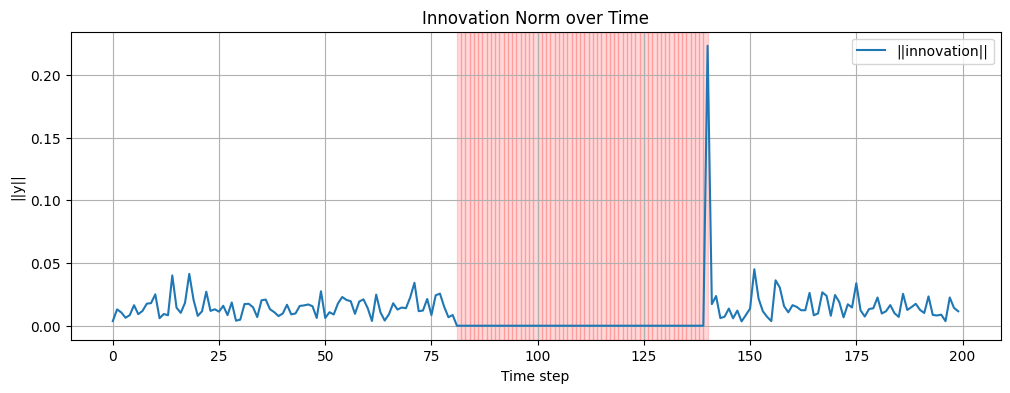

In [44]:
plt.figure(figsize=(12,4))

plt.plot(innov_norm, label="||innovation||")

for k, visible in enumerate(camera_availability):
    if not visible:
        plt.axvspan(k, k+1, color='red', alpha=0.15)

plt.title("Innovation Norm over Time")
plt.xlabel("Time step")
plt.ylabel("||y||")
plt.grid(True)
plt.legend()
plt.show()
